In [42]:
import numpy as np 
import tensorflow as tf
from tensorflow.keras import layers, models

Model 1 Training Data: (42000, 28, 28, 1), Labels: (42000,)
Model 2 Training Data: (18000, 28, 28, 1), Labels: (18000,)


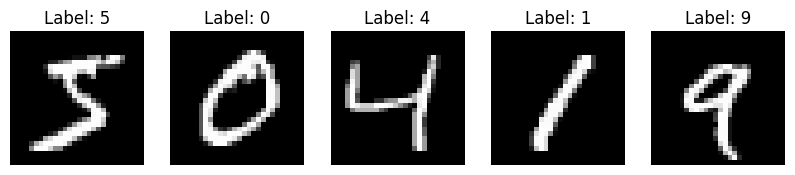

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Function to read .ubyte dataset
def read_idx(filename):
    with open(filename, 'rb') as f:
        data = f.read()
        magic = int.from_bytes(data[0:4], 'big')
        size = int.from_bytes(data[4:8], 'big')
        if magic == 2051:  # Images
            rows = int.from_bytes(data[8:12], 'big')
            cols = int.from_bytes(data[12:16], 'big')
            images = np.frombuffer(data, dtype=np.uint8, offset=16).reshape(size, rows, cols)
            return images
        elif magic == 2049:  # Labels
            labels = np.frombuffer(data, dtype=np.uint8, offset=8)
            return labels

# Load the dataset
train_images_path = './MNIST/train-images-idx3-ubyte'
train_labels_path = './MNIST/train-labels-idx1-ubyte'

x = read_idx(train_images_path)  # Load images
y = read_idx(train_labels_path)  # Load labels

# Normalize and reshape the data
x = x / 255.0
x = x.reshape(-1, 28, 28, 1)

# Split the dataset manually into 70% for Model 1 and 30% for Model 2
split_index = int(0.7 * len(x))  # Calculate 70% split index

x_train_1, y_train_1 = x[:split_index], y[:split_index]  # Model 1 dataset
x_train_2, y_train_2 = x[split_index:], y[split_index:]  # Model 2 dataset

# Verify the splits
print(f"Model 1 Training Data: {x_train_1.shape}, Labels: {y_train_1.shape}")
print(f"Model 2 Training Data: {x_train_2.shape}, Labels: {y_train_2.shape}")

# Display the first 5 images in the x_train_1 dataset
def show_images(images, labels):
    plt.figure(figsize=(10, 10))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.show()

# Show the first 5 images from Model 1 dataset (x_train_1)
show_images(x_train_1, y_train_1)


In [ ]:
# Define the first CNN architecture
def cnn_model_1():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Compile and train the first CNN using the first 70% of the dataset
model1 = cnn_model_1()
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1.summary()
#model1.fit(x_train_1, y_train_1, epochs=10, batch_size=64)

print("\nEvaluating Model 1 on its training data:")
model1.evaluate(x_train_1, y_train_1)

model1.save('mnist_cnn_model1_70split.keras')


Model: "sequential_28"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_73 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_73 (MaxPoolin  (None, 13, 13, 32)       0         
 g2D)                                                            
                                                                 
 flatten_27 (Flatten)        (None, 5408)              0         
                                                                 
 dense_81 (Dense)            (None, 64)                346176    
                                                                 
 dense_82 (Dense)            (None, 10)                650       
                                                                 
Total params: 347,146
Trainable params: 347,146
Non-trainable params: 0
_______________________________________________

In [77]:
# Define the second CNN architecture
def cnn_model_2():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        #layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Compile and train the second CNN using the last 30% of the dataset
model2 = cnn_model_2()
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()
model2.fit(x_train_2, y_train_2, epochs=10, batch_size=64)


# Evaluate both models on their respective datasets

print("\nEvaluating Model 2 on its training data:")
model2.evaluate(x_train_2, y_train_2)

# Save both models

model2.save('mnist_cnn_model2_30split.keras')

Model: "sequential_29"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_74 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_74 (MaxPoolin  (None, 13, 13, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_75 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_75 (MaxPoolin  (None, 5, 5, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_76 (Conv2D)          (None, 3, 3, 128)         73856     
                                                                 
 max_pooling2d_76 (MaxPoolin  (None, 1, 1, 128)      

In [78]:
model1 = load_model('./mnist_cnn_model1_70split.keras')
model2 = load_model('./mnist_cnn_model2_30split.keras')
model1_weights=model1.get_weights()
a=model1.layers[4].get_weights()
b=model2.layers[8].get_weights()
c=[(np.add(a[i],b[i]))/2 for i in range(len(a))]
print(len(a))
print(len(b))
print(c)

2
2
[array([[-0.09739665,  0.09689525,  0.08757359, -0.1271449 , -0.20537888,
        -0.40884584,  0.078519  ,  0.09788966, -0.05438133, -0.1311125 ],
       [-0.05767576, -0.04723667, -0.05129878,  0.19940594,  0.24954319,
        -0.08735658,  0.14738768,  0.02663756,  0.13718478,  0.10028434],
       [-0.2073766 ,  0.10890002, -0.01137548,  0.09907853, -0.16354641,
         0.07022233, -0.06792685,  0.16142616, -0.06128488, -0.20274612],
       [-0.0708721 ,  0.12971804,  0.17123964,  0.12178814,  0.07592262,
        -0.31873515, -0.01756082, -0.21010901, -0.36507958,  0.10602996],
       [-0.03634275, -0.24864928,  0.038256  ,  0.04843719, -0.026893  ,
        -0.05100181, -0.29285434,  0.04737741, -0.04861577,  0.00185919],
       [ 0.22325173, -0.19155958, -0.1464082 ,  0.19551158, -0.254645  ,
         0.02790318,  0.04340486, -0.00932944,  0.01895963, -0.11083359],
       [ 0.2518435 , -0.1114763 , -0.0330978 , -0.17601901, -0.2043194 ,
         0.05131425, -0.01976604, -0.062

In [80]:
c_model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),#1-0 0
        layers.MaxPooling2D((2, 2)),#1-1 1
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),#2-0 2
        layers.MaxPooling2D((2, 2)),#2-1 3
        layers.Conv2D(128, (3, 3), activation='relu'),#2-2 4
        layers.MaxPooling2D((2, 2)),#2-3 5
        layers.Flatten(),#2-4 6
        #layers.Dense(128, activation='relu'),#2-5 7
        layers.Dense(64, activation='relu'),#2-6 8
        layers.Dense(10, activation='softmax')#2-7 and 1-4 9
    ])

c_model.summary()

c_model.layers[0].set_weights(model1.layers[0].get_weights())#0
c_model.layers[2].set_weights(model2.layers[2].get_weights())#2
c_model.layers[4].set_weights(model2.layers[4].get_weights())#4
#c_model.layers[7].set_weights(model2.layers[7].get_weights())#7
c_model.layers[7].set_weights(model2.layers[7].get_weights())#8
c_model.layers[8].set_weights(c)#9


c_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

c_model.save('mnist_cnn_c_model.keras')

Model: "sequential_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_80 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_80 (MaxPoolin  (None, 13, 13, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_81 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_81 (MaxPoolin  (None, 5, 5, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_82 (Conv2D)          (None, 3, 3, 128)         73856     
                                                                 
 max_pooling2d_82 (MaxPoolin  (None, 1, 1, 128)      

In [83]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load the saved models
model1 = load_model('./mnist_cnn_model1_70split.keras')
model2 = load_model('./mnist_cnn_model2_30split.keras')
c_model = load_model('./mnist_cnn_c_model.keras')

# Function to preprocess the uploaded image using OpenCV
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read the image in grayscale
    img = cv2.resize(img, (28, 28))                     # Resize to 28x28
    img_array = img / 255.0                             # Normalize pixel values to [0, 1]
    img_array = img_array.reshape(1, 28, 28, 1)         # Add batch dimension
    return img_array

# Function to predict the digit using a specific model
def predict_digit(model, image):
    prediction = model.predict(image)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    return predicted_digit, confidence

# Upload and predict
def predict_uploaded_image(image_path):
    # Preprocess the image
    processed_image = preprocess_image(image_path)
    
    # Predict using Model 1
    predicted_digit_1, confidence_1 = predict_digit(model1, processed_image)
    print(f"Model 1 Prediction: {predicted_digit_1} with confidence {confidence_1:.2f}%")
    
    # Predict using Model 2
    predicted_digit_2, confidence_2 = predict_digit(model2, processed_image)
    print(f"Model 2 Prediction: {predicted_digit_2} with confidence {confidence_2:.2f}%")

    predicted_digit_3, confidence_3 = predict_digit(c_model, processed_image)
    print(f"Combined Model  Prediction: {predicted_digit_3} with confidence {confidence_3:.2f}%")

# Example image path
image_path = './5.jpeg'
predict_uploaded_image(image_path)


1/1 [==============================] - 1s 1s/step
Model 1 Prediction: 5 with confidence 100.00%
1/1 [==============================] - 0s 158ms/step
Model 2 Prediction: 2 with confidence 65.04%
1/1 [==============================] - 0s 120ms/step
Combined Model  Prediction: 5 with confidence 33.30%
